In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [12]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [13]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [15]:
df.shape


(4000, 28)

In [16]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [18]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [20]:
df.isnull().sum()
df.duplicated().sum()
 

np.int64(0)

In [21]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [22]:
df["Season"].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [23]:
df["Crop"].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

In [24]:
df["State"].unique()

array(['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka',
       'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh'], dtype=object)

In [25]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

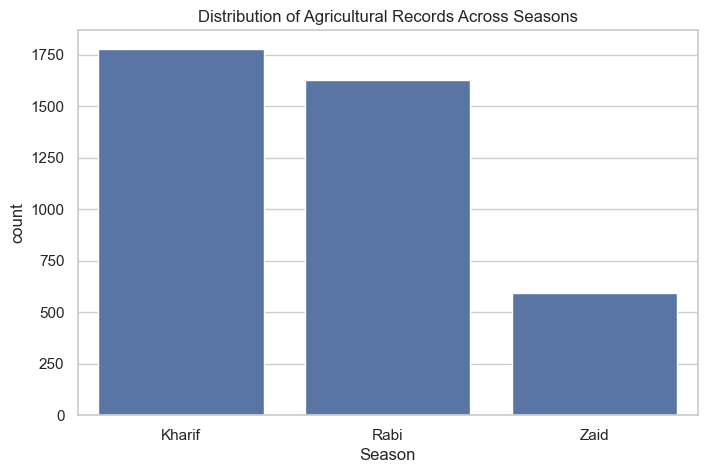

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Agricultural Records Across Seasons")
plt.show()

In [27]:
season_analysis = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Water_Used_m3": "mean"
})

print(season_analysis)

        Yield_Tonnes_Ha  Production_Tonnes    Revenue_INR     Profit_INR  \
Season                                                                     
Kharif         5.643973          46.311192  710719.055649  178914.647555   
Rabi           5.080498          41.486712  601526.048556   87689.470191   
Zaid           4.665942          38.886111  519171.904040  -24804.824916   

        Rainfall_mm  Avg_Temperature_C  Water_Used_m3  
Season                                                 
Kharif   852.084205          28.454019    6102.201237  
Rabi     436.000124          23.489183    5846.987093  
Zaid     299.421784          31.042088    6419.893939  


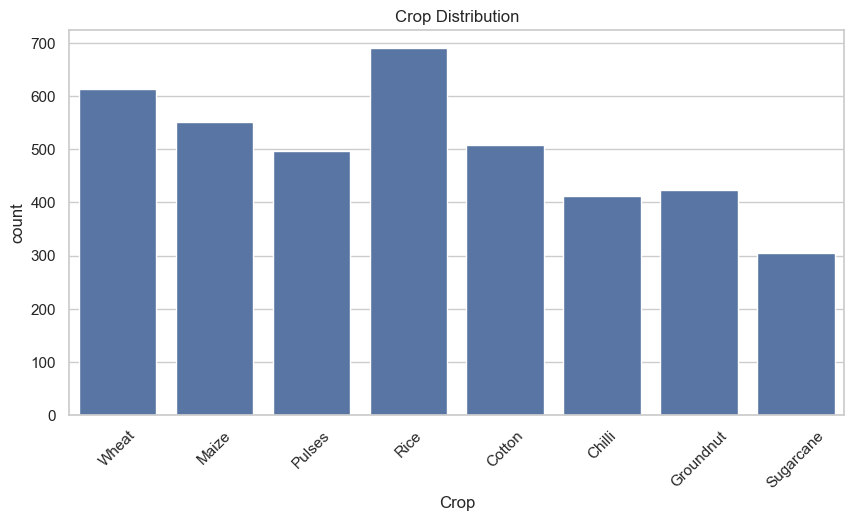

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Crop")
plt.xticks(rotation=45)
plt.title("Crop Distribution")
plt.show()

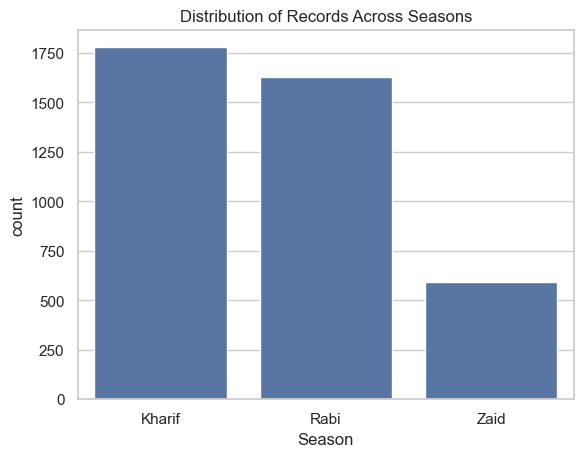

In [29]:
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records Across Seasons")
plt.show()

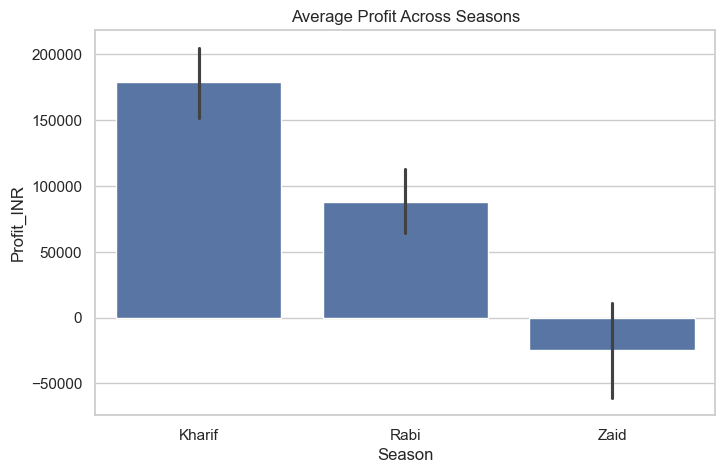

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator=np.mean
)

plt.title("Average Profit Across Seasons")
plt.show()

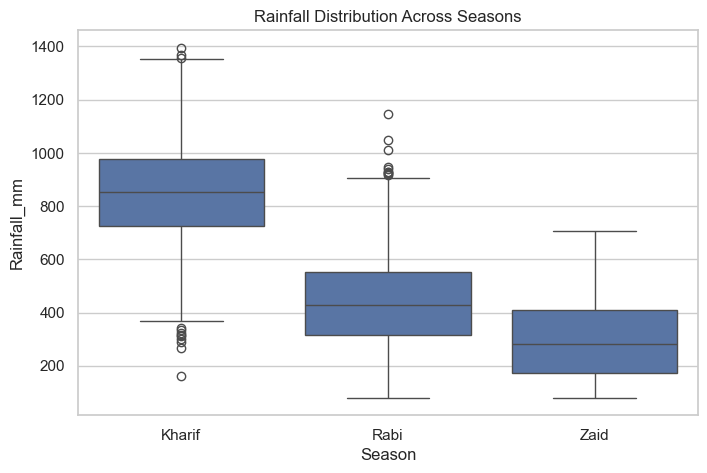

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Distribution Across Seasons")
plt.show()

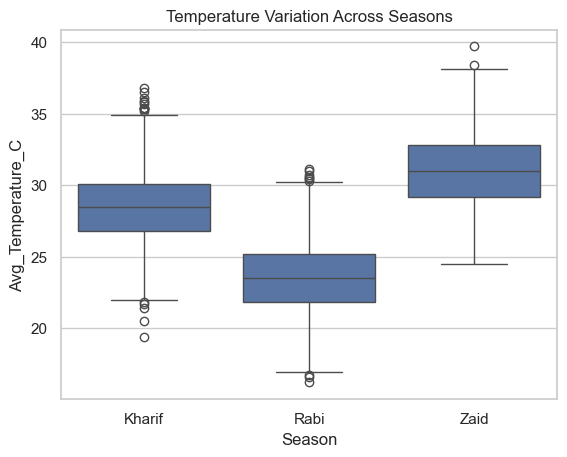

In [32]:
sns.boxplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Temperature Variation Across Seasons")
plt.show()

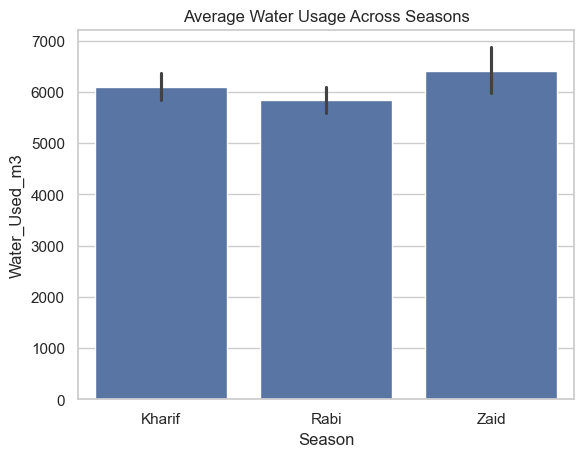

In [33]:
sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator=np.mean
)

plt.title("Average Water Usage Across Seasons")
plt.show()

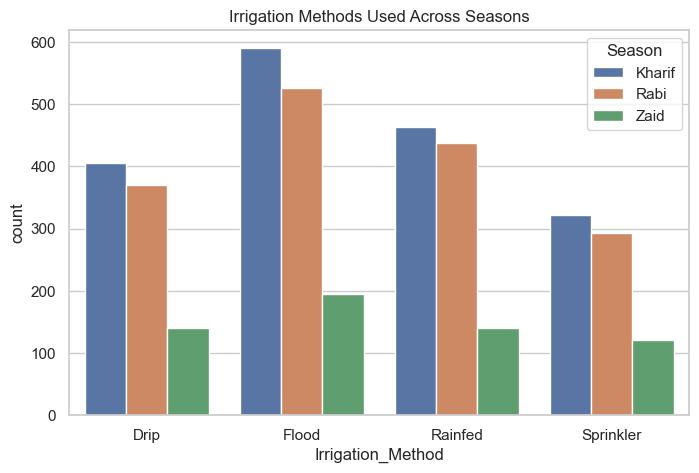

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Irrigation_Method",
    hue="Season"
)

plt.title("Irrigation Methods Used Across Seasons")
plt.show()

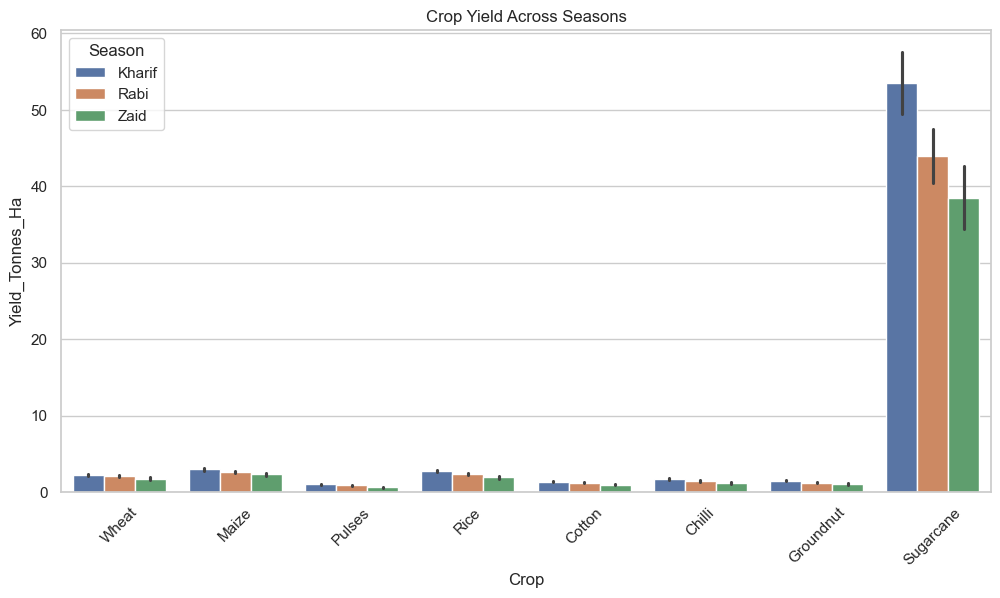

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.xticks(rotation=45)

plt.title("Crop Yield Across Seasons")
plt.show()

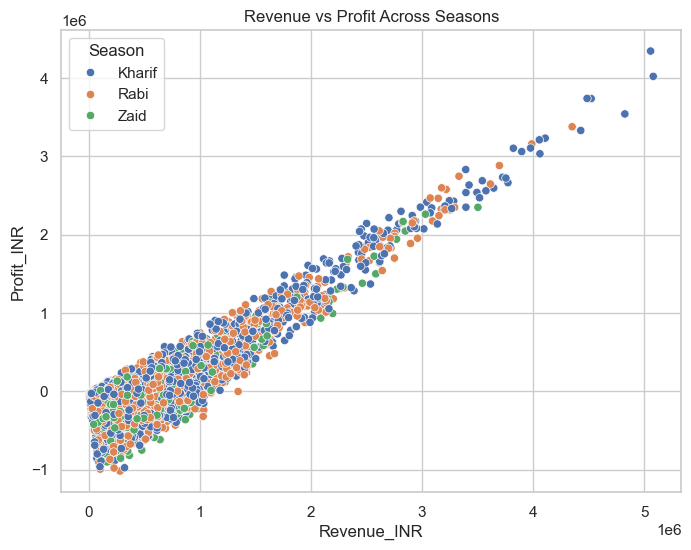

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Revenue_INR",
    y="Profit_INR",
    hue="Season"
)

plt.title("Revenue vs Profit Across Seasons")
plt.show()

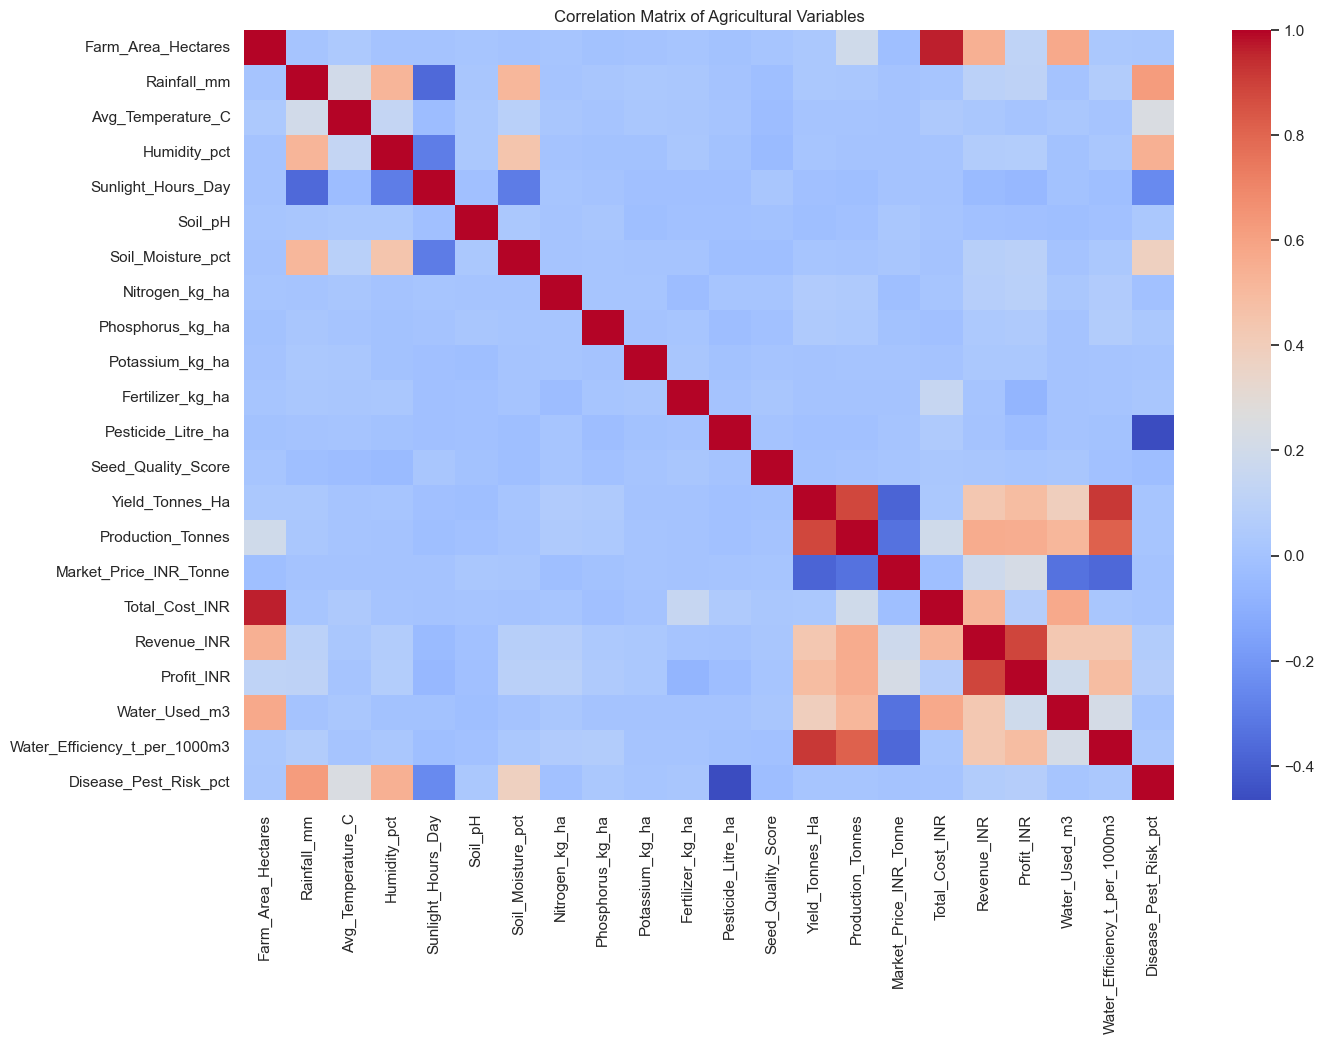

In [39]:
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(15,10))

sns.heatmap(
    numerical_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

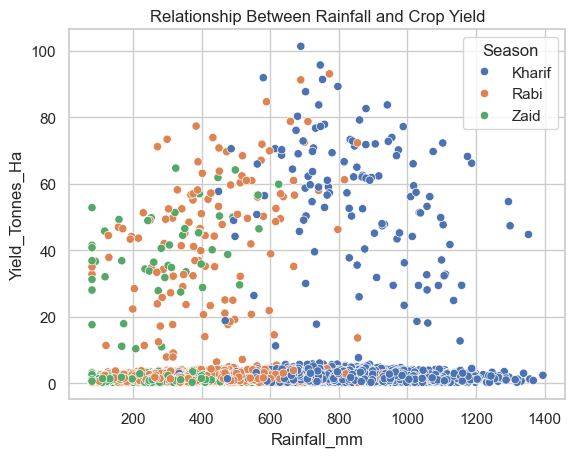

In [40]:
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Crop Yield")

plt.show()

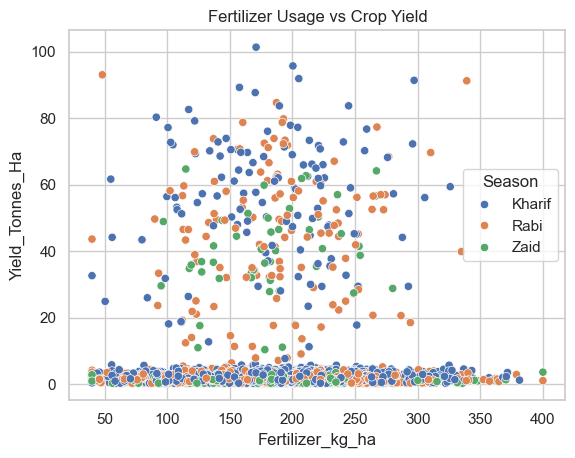

In [42]:
sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Fertilizer Usage vs Crop Yield")

plt.show()

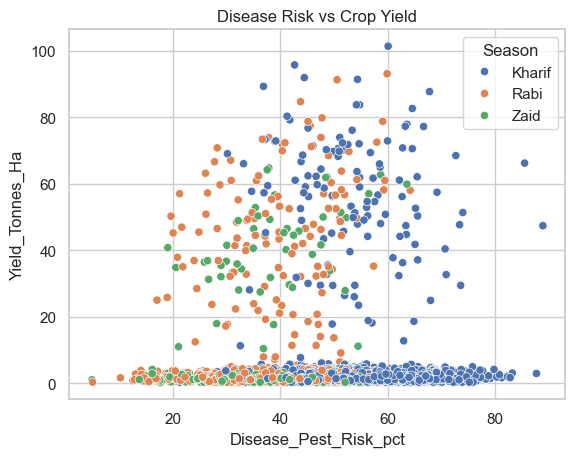

In [46]:
sns.scatterplot(
    data=df,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Disease Risk vs Crop Yield")

plt.show()

In [49]:
state_performance = df.groupby("State").agg({
    "Yield_Tonnes_Ha":"mean",
    "Profit_INR":"mean",
    "Production_Tonnes":"mean"
}).sort_values(by="Profit_INR", ascending=False)

print(state_performance.head(10))



                Yield_Tonnes_Ha     Profit_INR  Production_Tonnes
State                                                            
Punjab                 6.121116  136025.636364          52.233099
Maharashtra            5.030333  135428.855469          43.984043
Karnataka              5.734493  119422.335378          47.732720
Tamil Nadu             4.901247  117744.748454          40.840371
Gujarat                5.699586  117568.235656          48.331988
Telangana              5.076810  108829.616279          39.254186
Madhya Pradesh         5.029654   86840.756539          37.559517
Andhra Pradesh         4.650781   73453.527410          36.913157


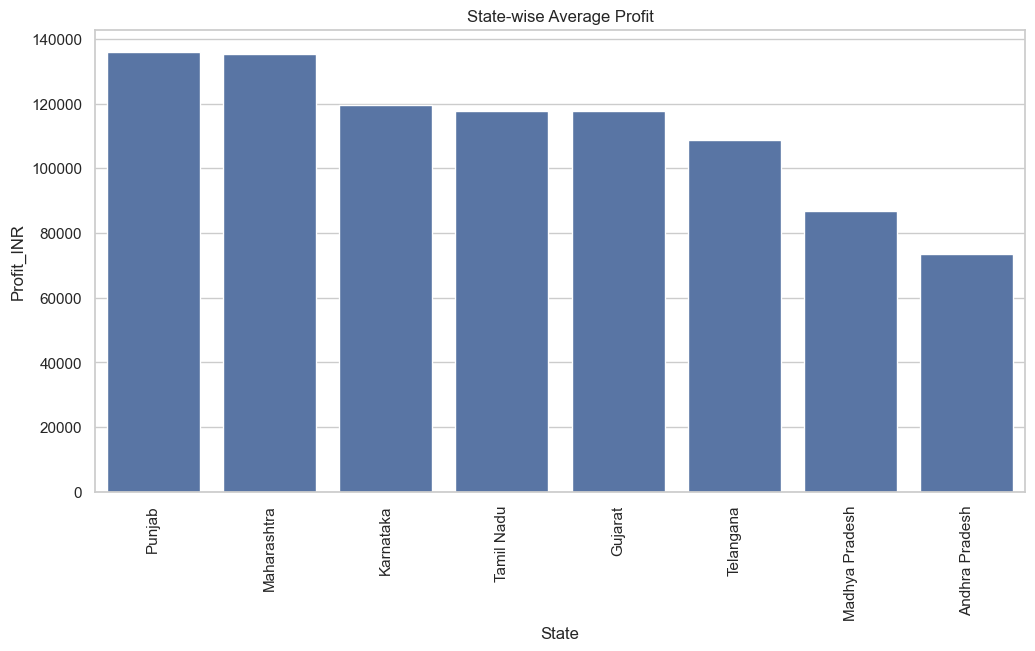

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_performance.reset_index(),
    x="State",
    y="Profit_INR"
)

plt.xticks(rotation=90)

plt.title("State-wise Average Profit")

plt.show()

In [51]:
crop_analysis = df.groupby("Crop").agg({
    "Yield_Tonnes_Ha":"mean",
    "Production_Tonnes":"mean",
    "Profit_INR":"mean"
})

print(crop_analysis)

           Yield_Tonnes_Ha  Production_Tonnes     Profit_INR
Crop                                                        
Chilli            1.540344          12.382888  750878.342233
Cotton            1.225734           9.395866  124546.915354
Groundnut         1.317924           9.655825   44858.120283
Maize             2.717130          21.781125  -83978.326679
Pulses            0.918198           7.401411   -4238.052419
Rice              2.439413          19.288623 -102213.504348
Sugarcane        46.938746         392.413016  817187.986885
Wheat             2.109216          16.853909 -123398.337134


In [53]:
seasons = df["Season"].unique()

groups = []

for season in seasons:
    groups.append(
        df[df["Season"] == season]["Yield_Tonnes_Ha"]
    )

f_stat, p_value = stats.f_oneway(*groups)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: nan
P Value: nan
